# Code Example on PPMS_Toolkit

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from ppms_toolkit.sample import Sample
from ppms_toolkit.measurement import HeatCapacityMeasurement

from ppms_toolkit.measurement import debye_model_extended, debye_model

## Heat Capacity on Mn-PEA

In [2]:
# Initialize a sample
s1 = Sample(id=1,
            name = "Mn-PEA",
            mass = 7.8, 
            make_time="2025-1-12")

In [3]:
# Load a measurement data and assign it to sample 1
Mn_PEA_HC = HeatCapacityMeasurement(filepath='test_data/HC_test_data.Dat',
                                    sample=s1, 
                                    field_strength=1000)

In [4]:
# Access to the list of Measurements
s1.measurements

[HC exp, Mn-PEA with 1000 Oe ]

In [5]:
# Access to the processed pd.DataFrame of certain measurements
s1.measurements[0].dataframe

,Time Stamp (Seconds),Sample Temp (Kelvin),Samp HC (µJ/K),Samp HC/Temp (µJ/K/K),Samp HC Err (µJ/K),Field (Oersted)
0,3.953442e+09,1.994420,0.909666,0.456104,0.002630,999.633427
1,3.953442e+09,2.199579,1.173588,0.533551,0.002645,999.669310
2,3.953442e+09,2.425263,1.529208,0.630533,0.003681,999.645383
3,3.953442e+09,2.673384,2.009654,0.751726,0.004339,999.513853
4,3.953442e+09,2.945506,2.601245,0.883123,0.005344,999.573647
...,...,...,...,...,...,...
155,3.953278e+09,258.597710,7473.481000,28.900028,20.690000,1000.034100
156,3.953268e+09,279.693800,8046.697200,28.769666,18.560000,999.998230
157,3.953276e+09,279.716630,8022.202300,28.679747,16.790000,999.908570
158,3.953268e+09,279.733640,8012.184900,28.642193,25.760000,1000.052000


In [6]:
# Save a certain sample with all its measurements and metadata to a pickle file.
s1.save()

In [7]:
# Load a Pickel file, later.
# s1 = Sample.load('Mn-PEA.pkl')

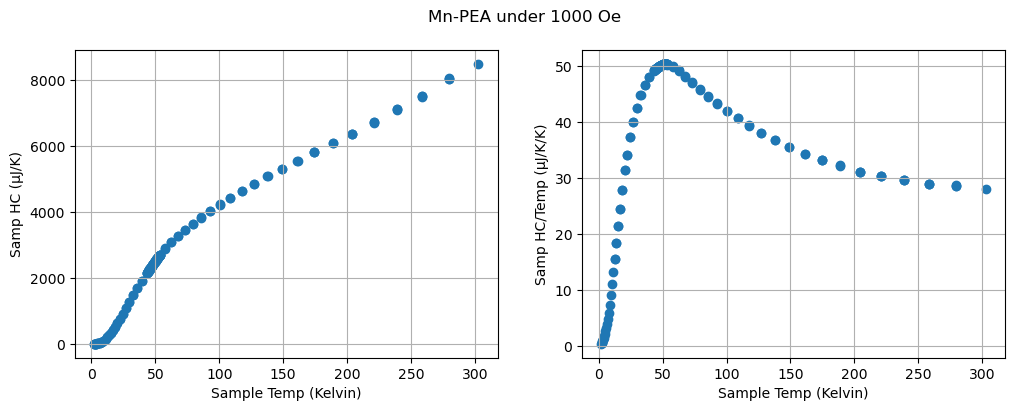

In [8]:
# plot the HC Data.
# The plot function returns the fig and ax object,
# so it's easy to manipulate and modify.
fig ,ax = Mn_PEA_HC.plot();

/Users/ryunosuke/Documents/Research/PPMS/PPMS_ToolKit/src/ppms_toolkit/measurement/utils.py:43: RuntimeWarning: overflow encountered in scalar power
  return np.where(denom == 0, 0, x**4 * ex / denom**2)


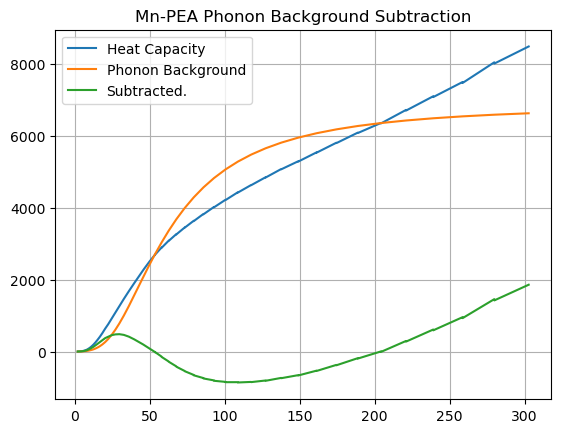

In [9]:
# Fit with default Debye Model, no bounding, no range.
T, subtracted_HC, fig, ax, params = Mn_PEA_HC.background_subtraction();

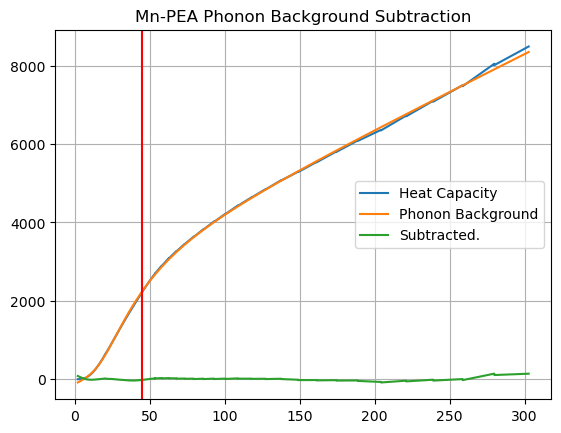

In [10]:
# Surely, you can fit with you own model function, with certain range and bounds to the fitting parameters.
T, subtracted_HC, fig, ax, params = Mn_PEA_HC.background_subtraction(model=debye_model_extended,
                                                                     mask_func=lambda T: (T>5) & (T<300),
                                                                     bounds=([1, 0.0001,-np.inf,-np.inf], 
                                                                             [500, 100,np.inf,np.inf]))

ax.axvline(x=44.7, c= 'r')

## VSM